In [1]:
import pandas as pd
import numpy as np
import joblib
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

# 1. Load Data, Targets, and Encoder

In [2]:
X_test = pd.read_csv("../dataset/X_test.csv")
y_test = pd.read_csv("../dataset/y_test.csv").squeeze()
label_encoder = joblib.load("../models/label_encoder.pkl")
crop_names = label_encoder.classes_

# 2. Load All Models

In [3]:
model_names = ["LogisticRegression", "KNN", "DecisionTree", "RandomForest", "SVM", "XGBoost", "LightGBM"]
models = {}
for name in model_names:
    models[name] = joblib.load(f"../models/{name}.pkl")

# 3. Define Noise Injection (Robustness Test)

In [4]:
def inject_sensor_noise(df, noise_level=0.05):
    """
    Injects Gaussian noise into the dataset to simulate real-world IoT sensor degradation.
    noise_level = 0.05 means noise with a standard deviation of 5% of the feature's original std.
    """
    df_noisy = df.copy()
    for col in df_noisy.columns:
        std_dev = df_noisy[col].std()
        noise = np.random.normal(0, std_dev * noise_level, size=len(df_noisy))
        df_noisy[col] = df_noisy[col] + noise
    return df_noisy

# Create Noisy Test Set (5% noise)
X_test_noisy = inject_sensor_noise(X_test, noise_level=0.05)

# 4. Evaluation Loop (Clean vs Noisy)

In [5]:
print("--- Starting Robustness Evaluation ---")
results = []

for name, model in models.items():
    # Clean Predictions
    y_pred_clean = model.predict(X_test)
    f1_clean = f1_score(y_test, y_pred_clean, average='macro')
    
    # Noisy Predictions
    y_pred_noisy = model.predict(X_test_noisy)
    f1_noisy = f1_score(y_test, y_pred_noisy, average='macro')
    
    # Calculate Drop
    f1_drop = f1_clean - f1_noisy
    
    results.append({
        "Model": name,
        "Clean_F1": f1_clean,
        "Noisy_F1": f1_noisy,
        "Performance_Drop": f1_drop
    })

--- Starting Robustness Evaluation ---


# 5. Robustness Ranking

In [6]:
results_df = pd.DataFrame(results).sort_values(by="Noisy_F1", ascending=False)
print("\nModel Robustness Ranking (Sorted by Noisy F1):")
print(results_df.to_string(index=False))
results_df.to_csv("../reports/robustness_results.csv", index=False)


Model Robustness Ranking (Sorted by Noisy F1):
             Model  Clean_F1  Noisy_F1  Performance_Drop
      RandomForest  0.995452  0.986411          0.009041
               SVM  0.984038  0.983995          0.000043
               KNN  0.979283  0.974784          0.004499
LogisticRegression  0.972464  0.965633          0.006831
      DecisionTree  0.979423  0.961029          0.018394
          LightGBM  0.988559  0.947696          0.040864
           XGBoost  0.993116  0.942967          0.050149


# 6. Detailed Analysis of the Most Robust Model

In [7]:
most_robust_name = results_df.iloc[0]["Model"]
best_model = models[most_robust_name]

print(f"\n--- Detailed Report for Most Robust Model ({most_robust_name}) on CLEAN data ---")
y_pred_best = best_model.predict(X_test)
print(classification_report(y_test, y_pred_best, target_names=crop_names))


--- Detailed Report for Most Robust Model (RandomForest) on CLEAN data ---
              precision    recall  f1-score   support

       apple       1.00      1.00      1.00        20
      banana       1.00      1.00      1.00        20
   blackgram       1.00      0.95      0.97        20
    chickpea       1.00      1.00      1.00        20
     coconut       1.00      1.00      1.00        20
      coffee       1.00      1.00      1.00        20
      cotton       1.00      1.00      1.00        20
      grapes       1.00      1.00      1.00        20
        jute       0.95      1.00      0.98        20
 kidneybeans       1.00      1.00      1.00        20
      lentil       1.00      1.00      1.00        20
       maize       0.95      1.00      0.98        20
       mango       1.00      1.00      1.00        20
   mothbeans       1.00      1.00      1.00        20
    mungbean       1.00      1.00      1.00        20
   muskmelon       1.00      1.00      1.00        20
     

# 7. Readable Confusion Matrix Plot


Saved high-res confusion matrix to reports folder.


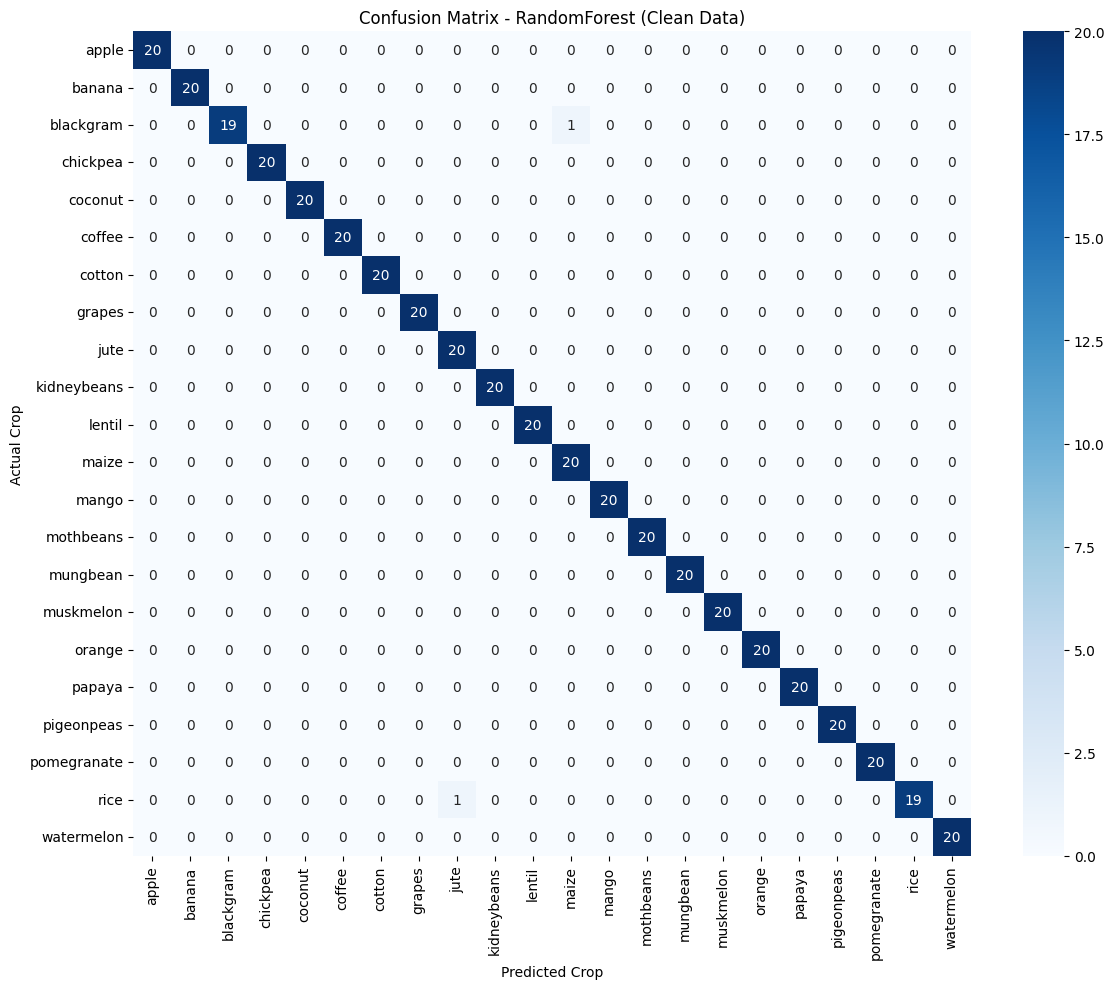

In [8]:
cm = confusion_matrix(y_test, y_pred_best)
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=crop_names, yticklabels=crop_names)
plt.title(f"Confusion Matrix - {most_robust_name} (Clean Data)")
plt.xlabel("Predicted Crop")
plt.ylabel("Actual Crop")
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig(f"../reports/confusion_matrix_{most_robust_name}.png")
print("\nSaved high-res confusion matrix to reports folder.")